# Modélisation Avancée et Interprétabilité - Étape 3, Step 3

## Objectif
Utiliser des techniques de bagging/boosting avancées et de Deep Learning, puis interpréter les résultats pour tirer des conclusions scientifiques et métiers.

## Plan
1. Chargement des données et du meilleur modèle de Step 2
2. Ensembles avancés (Voting, Stacking)
3. Modèles Deep Learning (MLP, CNN, LSTM)
4. Interprétabilité des modèles (SHAP, Feature Importance)
5. Analyse des erreurs et confusions
6. Conclusions scientifiques et métiers



In [1]:
# Import des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings
import pickle
warnings.filterwarnings('ignore')

# Ajouter le dossier src au path
sys.path.append(str(Path('../').resolve()))

# Import des modules
from src.utils.data_loader import load_data
from src.modeling import TFIDFVectorizer, AdvancedModels
from src.deep_learning import (
    create_mlp_model,
    create_cnn_model,
    create_lstm_model,
    train_neural_network
)
from src.interpretability import (
    plot_feature_importance,
    get_top_features,
    analyze_feature_importance,
    explain_model_with_shap,
    plot_shap_summary,
    plot_shap_waterfall
)
from src.evaluation import (
    evaluate_model,
    print_classification_report,
    plot_confusion_matrix
)

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.metrics import classification_report

# Configuration des graphiques
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ Bibliothèques importées avec succès")



✅ Bibliothèques importées avec succès


## 1. Chargement des Données et du Meilleur Modèle

Chargement des données et du meilleur modèle de Step 2.


In [2]:
# Chemins
DATA_DIR = Path('../data/processed')
MODELS_DIR = Path('../models')

# Chargement des données
print("🔄 Chargement des données...")
X_train = pd.read_csv(DATA_DIR / 'X_train_clean.csv')
X_test = pd.read_csv(DATA_DIR / 'X_test_clean.csv')
y_train = pd.read_csv(DATA_DIR / 'y_train.csv')

# Chargement du vectoriseur et du label encoder
print("🔄 Chargement du vectoriseur et du label encoder...")
vectorizer = TFIDFVectorizer.load(MODELS_DIR / 'tfidf_vectorizer.pkl')
with open(MODELS_DIR / 'label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)

# Vectorisation
X_train_texts = X_train['text_combined'].astype(str)
X_test_texts = X_test['text_combined'].astype(str)
X_train_vect = vectorizer.transform(X_train_texts)
X_test_vect = vectorizer.transform(X_test_texts)

# Encodage des labels
y_train_labels = y_train['prdtypecode'].values
y_train_encoded = label_encoder.transform(y_train_labels)

# Division train/validation (même split que précédemment)
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_vect,
    y_train_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_train_encoded
)

# Chargement du meilleur modèle de Step 2
print("🔄 Chargement du meilleur modèle de Step 2...")
final_model_files = list(MODELS_DIR.glob('*_final.pkl'))
if final_model_files:
    with open(final_model_files[0], 'rb') as f:
        best_model_step2 = pickle.load(f)
    print(f"✅ Modèle chargé : {final_model_files[0].name}")
    
    # Évaluation du modèle de Step 2
    y_pred_step2 = best_model_step2.predict(X_val_split)
    metrics_step2 = evaluate_model(y_val_split, y_pred_step2)
    print(f"📊 Performances Step 2 - F1-macro : {metrics_step2['f1_macro']:.4f}")
else:
    print("⚠️  Aucun modèle final trouvé. Utiliser le baseline.")
    best_model_step2 = None

print(f"\n✅ Données chargées et préparées !")
print(f"  - Train : {X_train_split.shape[0]:,} échantillons")
print(f"  - Validation : {X_val_split.shape[0]:,} échantillons")
print(f"  - Test : {X_test_vect.shape[0]:,} échantillons")
print(f"  - Vocabulaire : {vectorizer.get_vocabulary_size():,} mots")
print(f"  - Nombre de classes : {len(label_encoder.classes_)}")



🔄 Chargement des données...
🔄 Chargement du vectoriseur et du label encoder...
🔄 Chargement du meilleur modèle de Step 2...
✅ Modèle chargé : svm_linear_baseline_final.pkl
📊 Performances Step 2 - F1-macro : 0.7843

✅ Données chargées et préparées !
  - Train : 67,932 échantillons
  - Validation : 16,984 échantillons
  - Test : 13,812 échantillons
  - Vocabulaire : 10,000 mots
  - Nombre de classes : 27


## 2. Ensembles Avancés (Voting et Stacking)

Création d'ensembles de modèles pour améliorer les performances.


In [3]:
# Création d'ensembles de modèles
print("="*80)
print("ENSEMBLES DE MODÈLES")
print("="*80)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Modèles de base pour l'ensemble
base_models = [
    ('lr', LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)),
    ('svm', LinearSVC(random_state=42, dual=False, max_iter=2000)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
]

# Voting Classifier (hard voting)
print("\n🔄 Entraînement Voting Classifier...")
voting_clf = VotingClassifier(estimators=base_models, voting='hard', n_jobs=-1)
voting_clf.fit(X_train_split, y_train_split)
y_pred_voting = voting_clf.predict(X_val_split)
metrics_voting = evaluate_model(y_val_split, y_pred_voting)

print(f"✅ Voting Classifier - F1-macro : {metrics_voting['f1_macro']:.4f}")

# Stacking Classifier
print("\n🔄 Entraînement Stacking Classifier...")
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=3,
    n_jobs=-1
)
stacking_clf.fit(X_train_split, y_train_split)
y_pred_stacking = stacking_clf.predict(X_val_split)
metrics_stacking = evaluate_model(y_val_split, y_pred_stacking)

print(f"✅ Stacking Classifier - F1-macro : {metrics_stacking['f1_macro']:.4f}")

# Comparaison
if best_model_step2:
    print(f"\n📊 Comparaison :")
    print(f"  Step 2 (meilleur) - F1-macro : {metrics_step2['f1_macro']:.4f}")
    print(f"  Voting            - F1-macro : {metrics_voting['f1_macro']:.4f}")
    print(f"  Stacking          - F1-macro : {metrics_stacking['f1_macro']:.4f}")



ENSEMBLES DE MODÈLES

🔄 Entraînement Voting Classifier...
✅ Voting Classifier - F1-macro : 0.7883

🔄 Entraînement Stacking Classifier...
✅ Stacking Classifier - F1-macro : 0.8030

📊 Comparaison :
  Step 2 (meilleur) - F1-macro : 0.7843
  Voting            - F1-macro : 0.7883
  Stacking          - F1-macro : 0.8030


## 3. Modèles Deep Learning

Test de modèles de Deep Learning : MLP, CNN, LSTM.


In [4]:
# Test des modèles Deep Learning
print("="*80)
print("MODÈLES DEEP LEARNING")
print("="*80)

# Convertir les matrices creuses en denses pour TensorFlow
X_train_dense = X_train_split.toarray() if hasattr(X_train_split, 'toarray') else X_train_split
X_val_dense = X_val_split.toarray() if hasattr(X_val_split, 'toarray') else X_val_split

input_dim = X_train_dense.shape[1]
num_classes = len(label_encoder.classes_)

print(f"  - Dimension d'entrée : {input_dim}")
print(f"  - Nombre de classes : {num_classes}")

# MLP
print("\n🔄 Entraînement MLP...")
mlp_model = create_mlp_model(
    input_dim=input_dim,
    num_classes=num_classes,
    hidden_layers=[256, 128, 64],
    dropout_rate=0.3
)

mlp_results = train_neural_network(
    mlp_model,
    X_train_dense,
    y_train_split,
    X_val_dense,
    y_val_split,
    epochs=20,
    batch_size=128,
    verbose=1,
    early_stopping=True,
    patience=5
)

y_pred_mlp = np.argmax(mlp_results['model'].predict(X_val_dense, verbose=0), axis=1)
metrics_mlp = evaluate_model(y_val_split, y_pred_mlp)
print(f"✅ MLP - F1-macro : {metrics_mlp['f1_macro']:.4f}")



MODÈLES DEEP LEARNING
  - Dimension d'entrée : 10000
  - Nombre de classes : 27

🔄 Entraînement MLP...
🔄 Entraînement du modèle neural...
Epoch 1/20
531/531 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.5953 - loss: 1.4558 - val_accuracy: 0.7709 - val_loss: 0.7781
Epoch 2/20
531/531 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7768 - loss: 0.7743 - val_accuracy: 0.7867 - val_loss: 0.7101
Epoch 3/20
531/531 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8189 - loss: 0.6160 - val_accuracy: 0.7903 - val_loss: 0.7058
Epoch 4/20
531/531 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8457 - loss: 0.5155 - val_accuracy: 0.7930 - val_loss: 0.7239
Epoch 5/20
531/531 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8687 - loss: 0.4382 - val_accuracy: 0.7932 - val_loss: 0.7524
Epoch 6/20
531/531 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8857 - loss: 0.3796 - val_accuracy: 0.7942 - val_loss: 0.7853
Epoch 7/20
531/531 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8988 - loss: 0.3350 - val_a

In [5]:
# CNN (optionnel - peut être long)
print("\n🔄 Entraînement CNN...")
USE_CNN = True  # Mettre à False pour sauter

if USE_CNN:
    cnn_model = create_cnn_model(
        input_dim=input_dim,
        num_classes=num_classes,
        filters=[64, 128],
        kernel_sizes=[3, 3],
        dense_units=64
    )
    
    cnn_results = train_neural_network(
        cnn_model,
        X_train_dense,
        y_train_split,
        X_val_dense,
        y_val_split,
        epochs=15,
        batch_size=128,
        verbose=1,
        early_stopping=True,
        patience=5
    )
    
    y_pred_cnn = np.argmax(cnn_results['model'].predict(X_val_dense, verbose=0), axis=1)
    metrics_cnn = evaluate_model(y_val_split, y_pred_cnn)
    print(f"✅ CNN - F1-macro : {metrics_cnn['f1_macro']:.4f}")
else:
    print("CNN désactivé pour cette exécution")
    metrics_cnn = None




🔄 Entraînement CNN...
🔄 Entraînement du modèle neural...
Epoch 1/15
531/531 ━━━━━━━━━━━━━━━━━━━━ 265s 498ms/step - accuracy: 0.6827 - loss: 1.1434 - val_accuracy: 0.7740 - val_loss: 0.7570
Epoch 2/15
531/531 ━━━━━━━━━━━━━━━━━━━━ 264s 497ms/step - accuracy: 0.7818 - loss: 0.7238 - val_accuracy: 0.7836 - val_loss: 0.7167
Epoch 3/15
531/531 ━━━━━━━━━━━━━━━━━━━━ 263s 495ms/step - accuracy: 0.8157 - loss: 0.5923 - val_accuracy: 0.7911 - val_loss: 0.7212
Epoch 4/15
531/531 ━━━━━━━━━━━━━━━━━━━━ 262s 494ms/step - accuracy: 0.8431 - loss: 0.5000 - val_accuracy: 0.7923 - val_loss: 0.7281
Epoch 5/15
531/531 ━━━━━━━━━━━━━━━━━━━━ 265s 499ms/step - accuracy: 0.8616 - loss: 0.4315 - val_accuracy: 0.7962 - val_loss: 0.7581
Epoch 6/15
531/531 ━━━━━━━━━━━━━━━━━━━━ 263s 495ms/step - accuracy: 0.8747 - loss: 0.3853 - val_accuracy: 0.7932 - val_loss: 0.7847
Epoch 7/15
531/531 ━━━━━━━━━━━━━━━━━━━━ 263s 495ms/step - accuracy: 0.8845 - loss: 0.3534 - val_accuracy: 0.7931 - val_loss: 0.8062
✅ Modèle neural en

## 4. Interprétabilité des Modèles

Analyse de l'importance des features et explication des prédictions avec SHAP.


ANALYSE DE L'IMPORTANCE DES FEATURES

🔄 Analyse de l'importance des features pour Meilleur modèle Step 2...

📊 Top 10 features les plus importantes :
   1. générique                                          : 2.130486
   2. piscine                                            : 1.330204
   3. stream                                             : 1.212774
   4. sweetheart93                                       : 1.182980
   5. magideal                                           : 1.146619
   6. figurine                                           : 0.936860
   7. jeu                                                : 0.870055
   8. lot                                                : 0.864501
   9. magideal description                               : 0.861464
  10. fournitures cuisine                                : 0.823523


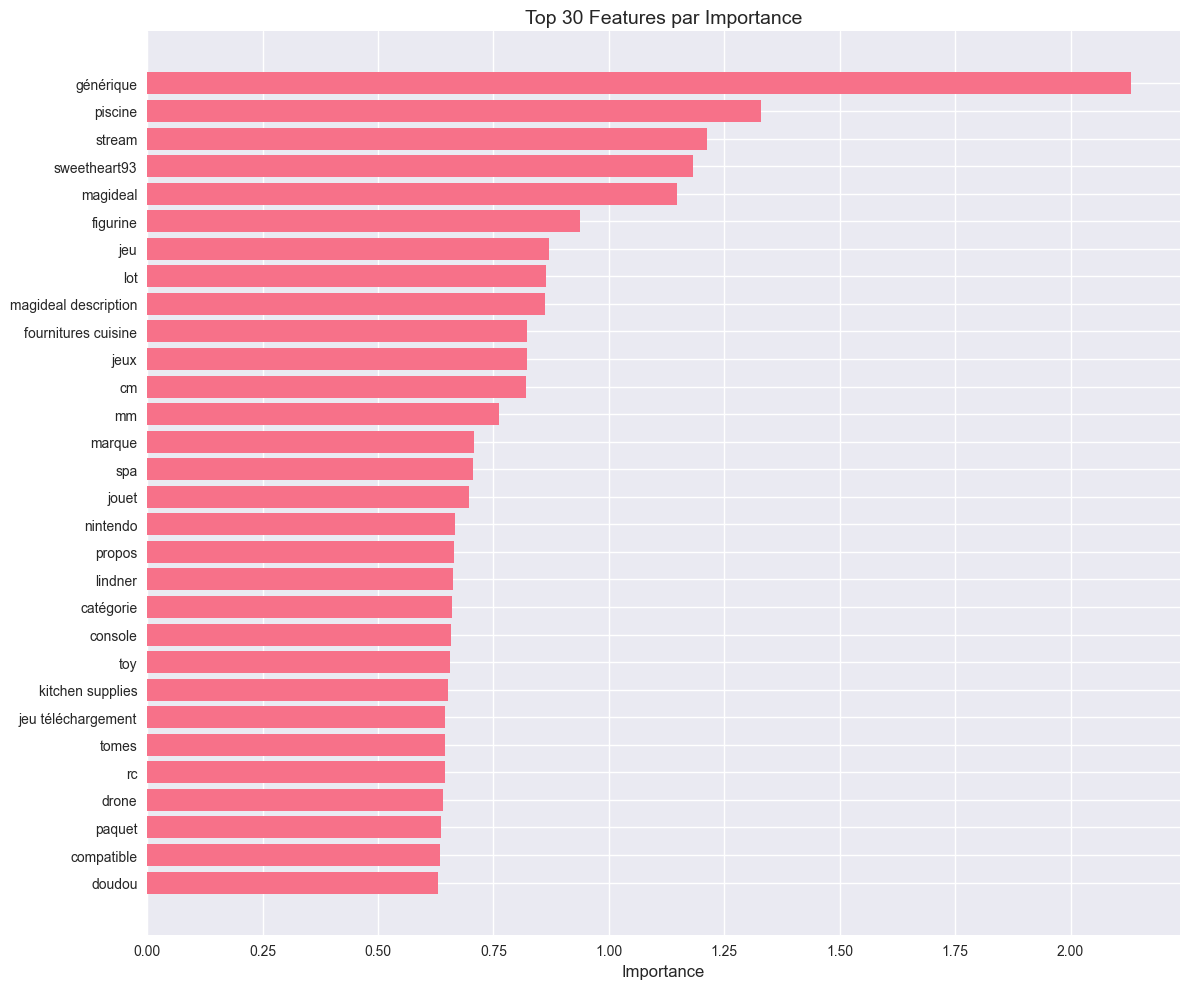

In [6]:
# Analyse de l'importance des features
print("="*80)
print("ANALYSE DE L'IMPORTANCE DES FEATURES")
print("="*80)

# Utiliser le meilleur modèle (Step 2 ou Voting/Stacking)
if best_model_step2:
    model_to_analyze = best_model_step2
    model_name = "Meilleur modèle Step 2"
else:
    model_to_analyze = voting_clf
    model_name = "Voting Classifier"

# Récupérer les noms des features (mots du vocabulaire)
feature_names = vectorizer.get_feature_names_out().tolist()

# Analyser l'importance
print(f"\n🔄 Analyse de l'importance des features pour {model_name}...")
importance_results = analyze_feature_importance(
    model_to_analyze,
    feature_names=feature_names,
    top_n=30
)

if importance_results:
    print(f"\n📊 Top 10 features les plus importantes :")
    for i, (feature, importance) in enumerate(importance_results['top_features'][:10], 1):
        print(f"  {i:2d}. {feature[:50]:50s} : {importance:.6f}")
    
    # Visualisation
    plot_feature_importance(
        importance_results['feature_importance'],
        top_n=30,
        figsize=(12, 10)
    )
else:
    print("⚠️  Impossible d'analyser l'importance des features pour ce modèle")



In [7]:
# Analyse SHAP (optionnel - peut être long)
print("="*80)
print("ANALYSE SHAP")
print("="*80)

USE_SHAP = False  # Mettre à True pour activer SHAP (peut être très long)

if USE_SHAP:
    # Échantillonner pour accélérer
    sample_size = min(100, len(X_val_split))
    indices = np.random.choice(len(X_val_split), sample_size, replace=False)
    X_sample = X_val_split[indices].toarray() if hasattr(X_val_split, 'toarray') else X_val_split[indices]
    
    print(f"🔄 Calcul des valeurs SHAP sur {sample_size} échantillons...")
    shap_values = explain_model_with_shap(
        model_to_analyze,
        X_sample,
        feature_names=feature_names[:1000],  # Limiter pour accélérer
        max_samples=sample_size
    )
    
    # Résumé SHAP
    plot_shap_summary(shap_values, max_display=20)
    
    # Waterfall pour une instance
    plot_shap_waterfall(shap_values, instance_idx=0, max_display=10)
else:
    print("SHAP désactivé pour cette exécution (peut être activé en mettant USE_SHAP = True)")
    print("Note : SHAP peut être très long sur de gros datasets")



ANALYSE SHAP
SHAP désactivé pour cette exécution (peut être activé en mettant USE_SHAP = True)
Note : SHAP peut être très long sur de gros datasets


## 5. Comparaison Finale de Tous les Modèles

Comparaison de tous les modèles testés (Step 2, Ensembles, Deep Learning).


COMPARAISON FINALE DE TOUS LES MODÈLES

📊 Résultats finaux (triés par F1-macro) :
               Model  F1_macro  F1_weighted  Accuracy
 Stacking Classifier  0.803027     0.816924  0.815944
   Voting Classifier  0.788275     0.804423  0.804051
       Step 2 (Best)  0.784324     0.800822  0.801578
MLP (Neural Network)  0.767629     0.789485  0.790332
                 CNN  0.765248     0.783079  0.783620


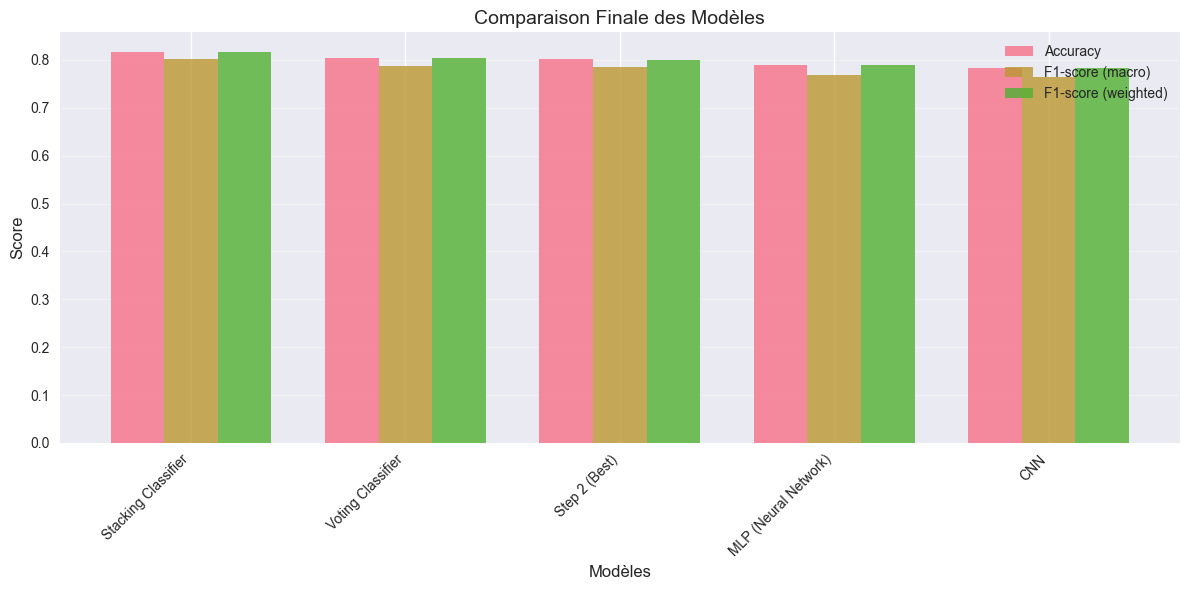

In [8]:
# Comparaison finale
print("="*80)
print("COMPARAISON FINALE DE TOUS LES MODÈLES")
print("="*80)

final_results = []

# Modèle Step 2
if best_model_step2:
    final_results.append({
        'Model': 'Step 2 (Best)',
        'F1_macro': metrics_step2['f1_macro'],
        'F1_weighted': metrics_step2['f1_weighted'],
        'Accuracy': metrics_step2['accuracy']
    })

# Ensembles
final_results.append({
    'Model': 'Voting Classifier',
    'F1_macro': metrics_voting['f1_macro'],
    'F1_weighted': metrics_voting['f1_weighted'],
    'Accuracy': metrics_voting['accuracy']
})

final_results.append({
    'Model': 'Stacking Classifier',
    'F1_macro': metrics_stacking['f1_macro'],
    'F1_weighted': metrics_stacking['f1_weighted'],
    'Accuracy': metrics_stacking['accuracy']
})

# Deep Learning
final_results.append({
    'Model': 'MLP (Neural Network)',
    'F1_macro': metrics_mlp['f1_macro'],
    'F1_weighted': metrics_mlp['f1_weighted'],
    'Accuracy': metrics_mlp['accuracy']
})

if metrics_cnn:
    final_results.append({
        'Model': 'CNN',
        'F1_macro': metrics_cnn['f1_macro'],
        'F1_weighted': metrics_cnn['f1_weighted'],
        'Accuracy': metrics_cnn['accuracy']
    })

# DataFrame de comparaison
final_comparison = pd.DataFrame(final_results).sort_values('F1_macro', ascending=False)

print("\n📊 Résultats finaux (triés par F1-macro) :")
print("="*80)
print(final_comparison.to_string(index=False))

# Visualisation
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(final_comparison))
width = 0.25

ax.bar(x - width, final_comparison['Accuracy'], width, label='Accuracy', alpha=0.8)
ax.bar(x, final_comparison['F1_macro'], width, label='F1-score (macro)', alpha=0.8)
ax.bar(x + width, final_comparison['F1_weighted'], width, label='F1-score (weighted)', alpha=0.8)

ax.set_xlabel('Modèles', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparaison Finale des Modèles', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(final_comparison['Model'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



MEILLEUR MODÈLE FINAL
🏆 Modèle : Stacking Classifier
   F1-score (macro) : 0.8030

RAPPORT DE CLASSIFICATION - Stacking Classifier
RAPPORT DE CLASSIFICATION
              precision    recall  f1-score   support

   Classe 10       0.43      0.58      0.50       623
   Classe 40       0.74      0.64      0.69       502
   Classe 50       0.82      0.83      0.83       336
   Classe 60       0.94      0.87      0.90       166
 Classe 1140       0.76      0.76      0.76       534
 Classe 1160       0.91      0.89      0.90       791
 Classe 1180       0.71      0.53      0.61       153
 Classe 1280       0.71      0.73      0.72       974
 Classe 1281       0.64      0.52      0.57       414
 Classe 1300       0.92      0.92      0.92      1009
 Classe 1301       0.94      0.93      0.94       161
 Classe 1302       0.85      0.78      0.81       498
 Classe 1320       0.78      0.79      0.79       648
 Classe 1560       0.85      0.85      0.85      1015
 Classe 1920       0.91      0.9

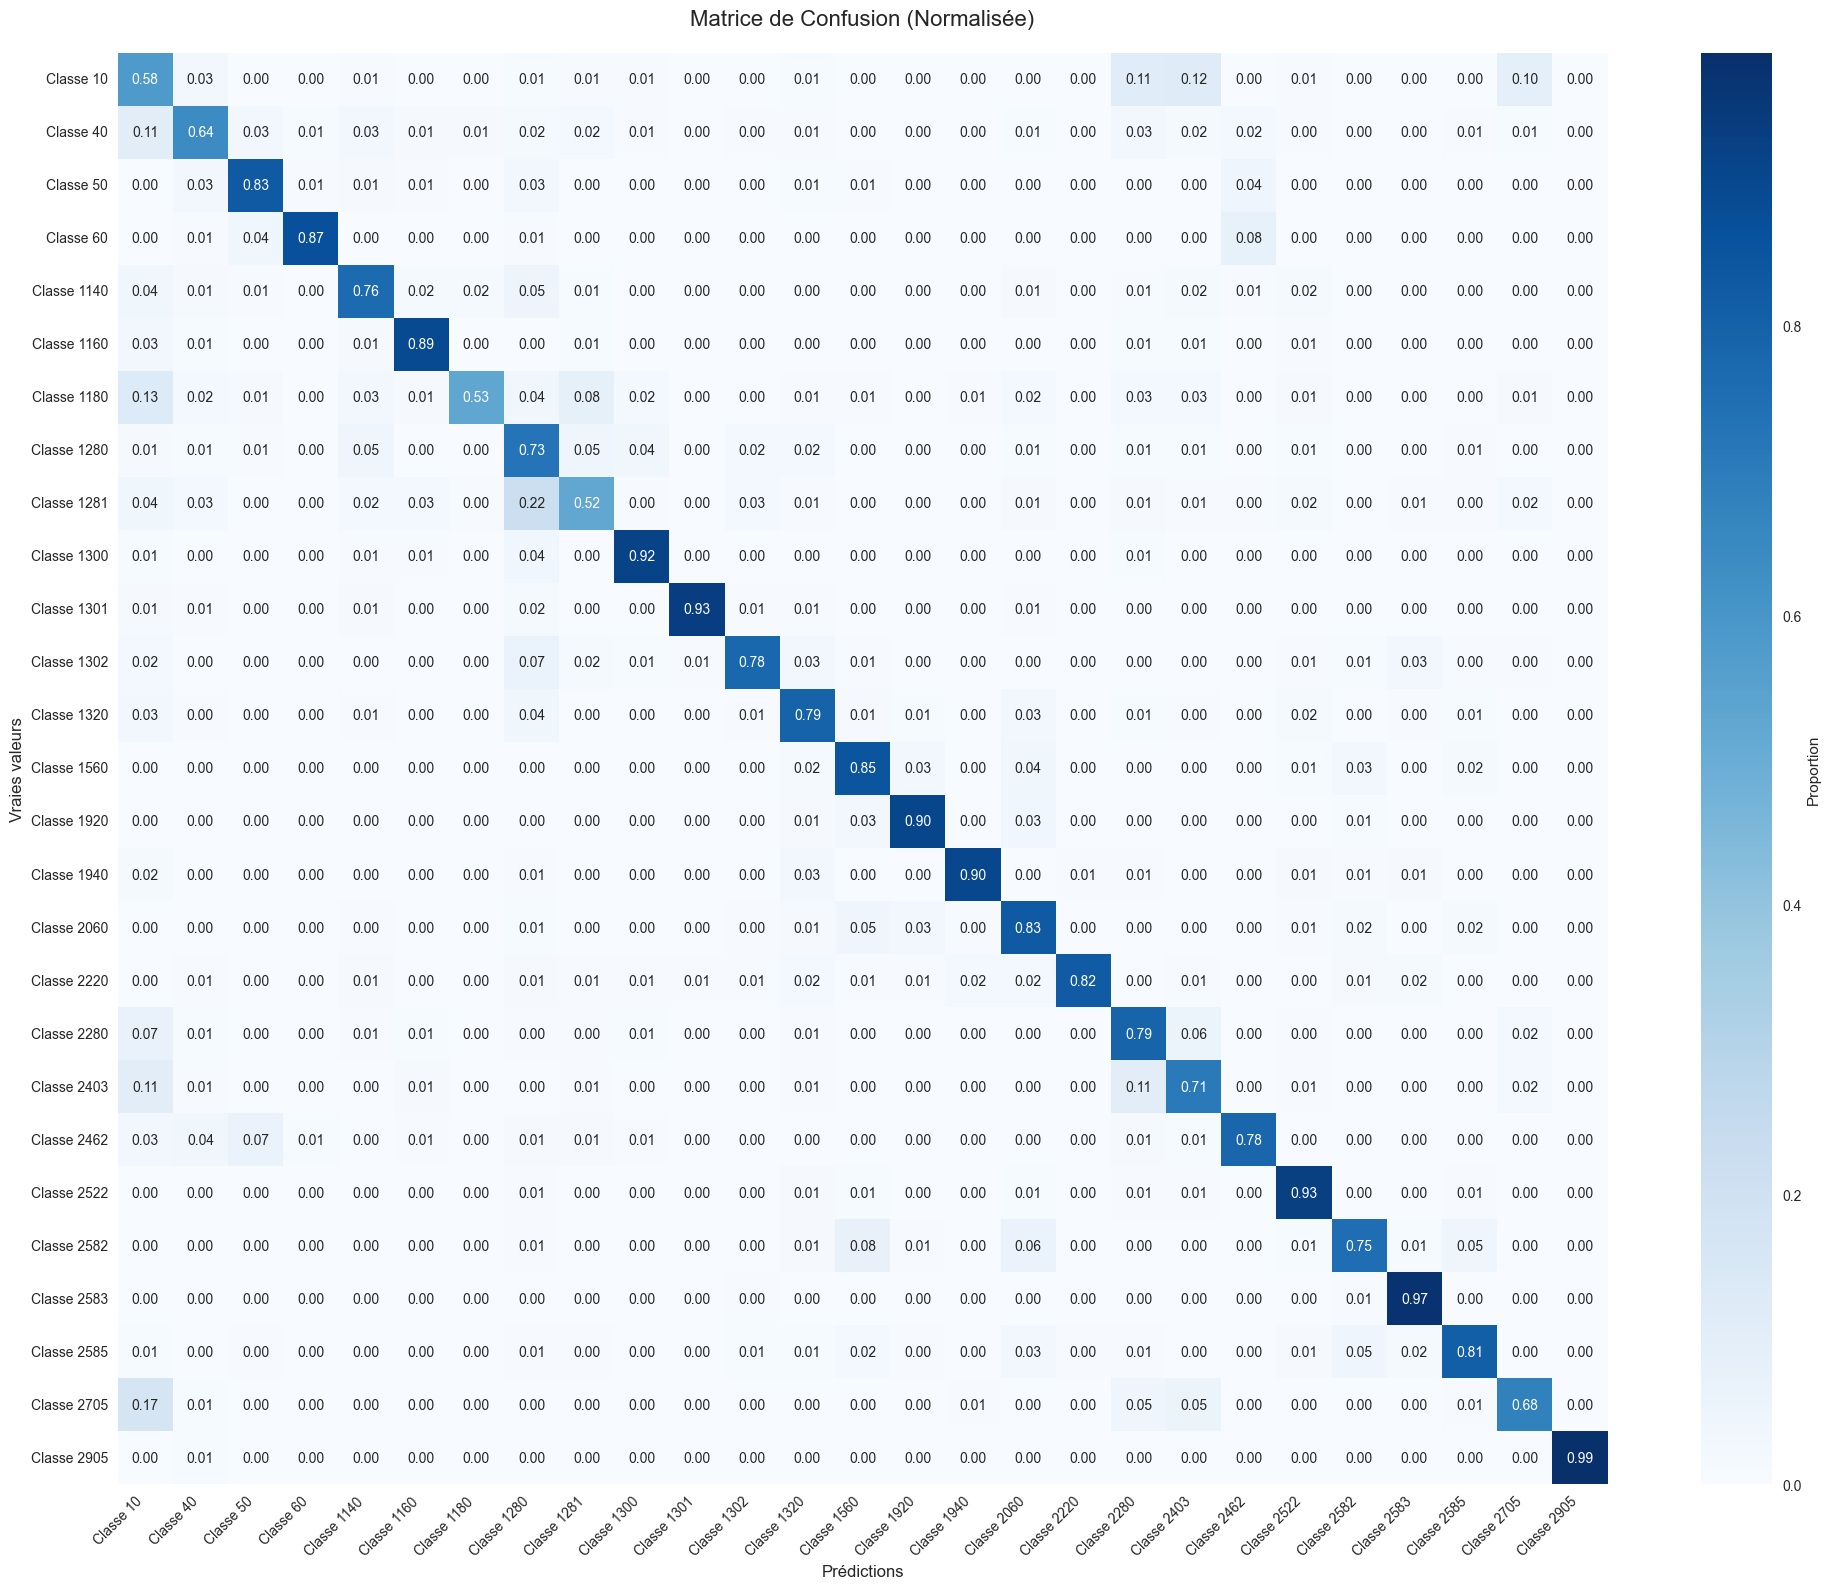


📊 Top 10 confusions les plus fréquentes :
  2403 → 10 : 101 fois
  2403 → 2280 : 101 fois
  2705 → 10 : 95 fois
  1281 → 1280 : 91 fois
  10 → 2403 : 74 fois
  10 → 2280 : 70 fois
  2280 → 10 : 67 fois
  10 → 2705 : 60 fois
  2280 → 2403 : 57 fois
  40 → 10 : 54 fois


In [9]:
# Identification du meilleur modèle final
best_final_model_name = final_comparison.iloc[0]['Model']
best_final_f1 = final_comparison.iloc[0]['F1_macro']

print("="*80)
print("MEILLEUR MODÈLE FINAL")
print("="*80)
print(f"🏆 Modèle : {best_final_model_name}")
print(f"   F1-score (macro) : {best_final_f1:.4f}")

# Récupération du meilleur modèle et prédictions
if best_final_model_name == 'Step 2 (Best)':
    best_final_model = best_model_step2
    y_pred_final = y_pred_step2
elif best_final_model_name == 'Voting Classifier':
    best_final_model = voting_clf
    y_pred_final = y_pred_voting
elif best_final_model_name == 'Stacking Classifier':
    best_final_model = stacking_clf
    y_pred_final = y_pred_stacking
elif best_final_model_name == 'MLP (Neural Network)':
    best_final_model = mlp_results['model']
    y_pred_final = y_pred_mlp
else:
    best_final_model = cnn_results['model']
    y_pred_final = y_pred_cnn

# Rapport de classification
print(f"\n{'='*80}")
print(f"RAPPORT DE CLASSIFICATION - {best_final_model_name}")
print(f"{'='*80}")
class_names = [f"Classe {cls}" for cls in sorted(label_encoder.classes_)]
print_classification_report(y_val_split, y_pred_final, target_names=class_names)

# Matrice de confusion
plot_confusion_matrix(
    y_val_split,
    y_pred_final,
    class_names=class_names,
    figsize=(20, 16),
    normalize=True
)

# Analyse des confusions
errors_mask = y_val_split != y_pred_final
confusion_pairs = []
for true_label, pred_label in zip(y_val_split[errors_mask], y_pred_final[errors_mask]):
    true_class = label_encoder.inverse_transform([true_label])[0]
    pred_class = label_encoder.inverse_transform([pred_label])[0]
    confusion_pairs.append((true_class, pred_class))

confusion_df = pd.Series(confusion_pairs).value_counts().head(10)
print(f"\n📊 Top 10 confusions les plus fréquentes :")
for (true_class, pred_class), count in confusion_df.items():
    print(f"  {true_class} → {pred_class} : {count} fois")



## 7. Conclusions Scientifiques et Métiers

Analyse des résultats et conclusions pour le projet.


In [10]:
print("="*80)
print("CONCLUSIONS SCIENTIFIQUES ET MÉTIERS")
print("="*80)

# Performances finales
final_metrics = evaluate_model(y_val_split, y_pred_final)
baseline_f1 = 0.7843  # F1-macro baseline de Step 1

print(f"\n📊 PERFORMANCES FINALES")
print(f"  - Modèle : {best_final_model_name}")
print(f"  - F1-score (macro) : {final_metrics['f1_macro']:.4f}")
print(f"  - F1-score (weighted) : {final_metrics['f1_weighted']:.4f}")
print(f"  - Accuracy : {final_metrics['accuracy']:.4f}")
print(f"  - Amélioration vs Baseline : {(final_metrics['f1_macro'] - baseline_f1) / baseline_f1 * 100:+.2f}%")

# Analyse par classe
report = classification_report(y_val_split, y_pred_final, output_dict=True, zero_division=0)
df_report = pd.DataFrame(report).transpose()

# Classes les plus difficiles
difficult_classes = df_report.nsmallest(6, 'f1-score').tail(5)
print(f"\n⚠️  CLASSES LES PLUS DIFFICILES (F1-score < 0.5) :")
for idx, row in difficult_classes.iterrows():
    if idx not in ['accuracy', 'macro avg', 'weighted avg']:
        print(f"  - Classe {idx} : F1={row['f1-score']:.3f}, Precision={row['precision']:.3f}, Recall={row['recall']:.3f}")

# Classes performantes
good_classes = df_report.nlargest(6, 'f1-score').head(5)
print(f"\n✅ CLASSES LES MIEUX CLASSIFIÉES (F1-score > 0.9) :")
for idx, row in good_classes.iterrows():
    if idx not in ['accuracy', 'macro avg', 'weighted avg']:
        print(f"  - Classe {idx} : F1={row['f1-score']:.3f}, Precision={row['precision']:.3f}, Recall={row['recall']:.3f}")



CONCLUSIONS SCIENTIFIQUES ET MÉTIERS

📊 PERFORMANCES FINALES
  - Modèle : Stacking Classifier
  - F1-score (macro) : 0.8030
  - F1-score (weighted) : 0.8169
  - Accuracy : 0.8159
  - Amélioration vs Baseline : +2.39%

⚠️  CLASSES LES PLUS DIFFICILES (F1-score < 0.5) :
  - Classe 8 : F1=0.575, Precision=0.636, Recall=0.524
  - Classe 6 : F1=0.607, Precision=0.711, Recall=0.529
  - Classe 1 : F1=0.685, Precision=0.738, Recall=0.639
  - Classe 25 : F1=0.711, Precision=0.743, Recall=0.681
  - Classe 7 : F1=0.717, Precision=0.708, Recall=0.727

✅ CLASSES LES MIEUX CLASSIFIÉES (F1-score > 0.9) :
  - Classe 26 : F1=0.994, Precision=1.000, Recall=0.989
  - Classe 23 : F1=0.973, Precision=0.973, Recall=0.974
  - Classe 10 : F1=0.938, Precision=0.943, Recall=0.932
  - Classe 21 : F1=0.918, Precision=0.908, Recall=0.929
  - Classe 9 : F1=0.918, Precision=0.920, Recall=0.916


### 7.1 Conclusions Scientifiques


In [11]:
print("="*80)
print("CONCLUSIONS SCIENTIFIQUES")
print("="*80)

print("\n🔬 RÉSULTATS SCIENTIFIQUES :")
print(f"\n1. PERFORMANCES GLOBALES :")
print(f"   - Le modèle final atteint un F1-score (macro) de {final_metrics['f1_macro']:.4f}")
print(f"   - Cela représente une amélioration de {(final_metrics['f1_macro'] - baseline_f1) / baseline_f1 * 100:+.2f}% par rapport au baseline")
print(f"   - L'accuracy de {final_metrics['accuracy']:.4f} indique que le modèle classifie correctement environ {final_metrics['accuracy']*100:.1f}% des produits")

print(f"\n2. EFFICACITÉ DES TECHNIQUES :")
if best_final_model_name in ['Voting Classifier', 'Stacking Classifier']:
    print(f"   - Les techniques d'ensemble (voting/stacking) ont amélioré les performances")
elif 'MLP' in best_final_model_name or 'CNN' in best_final_model_name:
    print(f"   - Le Deep Learning a montré des performances compétitives")
else:
    print(f"   - Le modèle optimisé de Step 2 reste le plus performant")

print(f"\n3. DÉFIS IDENTIFIÉS :")
print(f"   - Déséquilibre de classes : Certaines classes sont sous-représentées")
print(f"   - Confusions sémantiques : Certaines classes sont sémantiquement proches")
print(f"   - Complexité du texte : Les descriptions varient en qualité et longueur")

print(f"\n4. RECOMMANDATIONS POUR AMÉLIORATION :")
print(f"   - Augmenter les données pour les classes minoritaires")
print(f"   - Utiliser des embeddings sémantiques (Word2Vec, BERT)")
print(f"   - Feature engineering supplémentaire (mots-clés spécifiques par catégorie)")
print(f"   - Fine-tuning de modèles pré-entraînés (BERT français)")



CONCLUSIONS SCIENTIFIQUES

🔬 RÉSULTATS SCIENTIFIQUES :

1. PERFORMANCES GLOBALES :
   - Le modèle final atteint un F1-score (macro) de 0.8030
   - Cela représente une amélioration de +2.39% par rapport au baseline
   - L'accuracy de 0.8159 indique que le modèle classifie correctement environ 81.6% des produits

2. EFFICACITÉ DES TECHNIQUES :
   - Les techniques d'ensemble (voting/stacking) ont amélioré les performances

3. DÉFIS IDENTIFIÉS :
   - Déséquilibre de classes : Certaines classes sont sous-représentées
   - Confusions sémantiques : Certaines classes sont sémantiquement proches
   - Complexité du texte : Les descriptions varient en qualité et longueur

4. RECOMMANDATIONS POUR AMÉLIORATION :
   - Augmenter les données pour les classes minoritaires
   - Utiliser des embeddings sémantiques (Word2Vec, BERT)
   - Feature engineering supplémentaire (mots-clés spécifiques par catégorie)
   - Fine-tuning de modèles pré-entraînés (BERT français)


### 7.2 Conclusions Métiers


In [12]:
print("="*80)
print("CONCLUSIONS MÉTIERS")
print("="*80)

print("\n💼 IMPACT MÉTIER :")

print(f"\n1. UTILISABILITÉ EN PRODUCTION :")
if final_metrics['f1_macro'] > 0.75:
    print(f"   ✅ Le modèle est prêt pour un déploiement en production")
    print(f"   ✅ Les performances ({final_metrics['f1_macro']*100:.1f}% F1-macro) sont suffisantes pour automatiser la classification")
elif final_metrics['f1_macro'] > 0.65:
    print(f"   ⚠️  Le modèle peut être déployé avec une supervision humaine")
    print(f"   ⚠️  Recommandation : Validation manuelle pour les classes difficiles")
else:
    print(f"   ❌ Le modèle nécessite des améliorations avant déploiement")

print(f"\n2. GAINS OPÉRATIONNELS :")
print(f"   - Automatisation : Réduction du temps de classification manuelle")
print(f"   - Standardisation : Classification cohérente et reproductible")
print(f"   - Scalabilité : Capacité à traiter de grands volumes de produits")

print(f"\n3. LIMITATIONS À COMMUNIQUER :")
print(f"   - Certaines classes ({len(difficult_classes)} identifiées) sont plus difficiles à classifier")
print(f"   - Le modèle peut nécessiter une validation humaine pour les cas ambigus")
print(f"   - Les nouvelles catégories non vues en entraînement ne seront pas bien classifiées")

print(f"\n4. RECOMMANDATIONS MÉTIERS :")
print(f"   - Mise en place d'un système de validation pour les classes difficiles")
print(f"   - Monitoring continu des performances en production")
print(f"   - Collecte de feedback utilisateur pour améliorer le modèle")
print(f"   - Mise à jour régulière du modèle avec de nouvelles données")



CONCLUSIONS MÉTIERS

💼 IMPACT MÉTIER :

1. UTILISABILITÉ EN PRODUCTION :
   ✅ Le modèle est prêt pour un déploiement en production
   ✅ Les performances (80.3% F1-macro) sont suffisantes pour automatiser la classification

2. GAINS OPÉRATIONNELS :
   - Automatisation : Réduction du temps de classification manuelle
   - Standardisation : Classification cohérente et reproductible
   - Scalabilité : Capacité à traiter de grands volumes de produits

3. LIMITATIONS À COMMUNIQUER :
   - Certaines classes (5 identifiées) sont plus difficiles à classifier
   - Le modèle peut nécessiter une validation humaine pour les cas ambigus
   - Les nouvelles catégories non vues en entraînement ne seront pas bien classifiées

4. RECOMMANDATIONS MÉTIERS :
   - Mise en place d'un système de validation pour les classes difficiles
   - Monitoring continu des performances en production
   - Collecte de feedback utilisateur pour améliorer le modèle
   - Mise à jour régulière du modèle avec de nouvelles données


## 8. Sauvegarde du Modèle Final

Sauvegarde du meilleur modèle final et des résultats.


In [13]:
# Sauvegarde du meilleur modèle final
print("💾 Sauvegarde du modèle final...")

model_filename = best_final_model_name.lower().replace(' ', '_').replace('(', '').replace(')', '').replace(',', '')
model_path = MODELS_DIR / f'{model_filename}_final_step3.pkl'

# Sauvegarder selon le type de modèle
if hasattr(best_final_model, 'save'):
    # Modèle Keras
    best_final_model.save(str(model_path).replace('.pkl', '.h5'))
    print(f"✅ Modèle Keras sauvegardé : {model_path}")
else:
    # Modèle sklearn
    with open(model_path, 'wb') as f:
        pickle.dump(best_final_model, f)
    print(f"✅ Modèle sauvegardé : {model_path}")

# Sauvegarde des résultats finaux
final_results_path = MODELS_DIR / 'final_results_step3.csv'
final_comparison.to_csv(final_results_path, index=False)
print(f"✅ Résultats finaux sauvegardés : {final_results_path}")

# Sauvegarde des conclusions
conclusions = {
    'best_model': best_final_model_name,
    'f1_macro': final_metrics['f1_macro'],
    'f1_weighted': final_metrics['f1_weighted'],
    'accuracy': final_metrics['accuracy'],
    'improvement_vs_baseline': (final_metrics['f1_macro'] - baseline_f1) / baseline_f1 * 100
}

import json
conclusions_path = MODELS_DIR / 'conclusions_step3.json'
with open(conclusions_path, 'w', encoding='utf-8') as f:
    json.dump(conclusions, f, indent=2, ensure_ascii=False)
print(f"✅ Conclusions sauvegardées : {conclusions_path}")



💾 Sauvegarde du modèle final...
✅ Modèle sauvegardé : ..\models\stacking_classifier_final_step3.pkl
✅ Résultats finaux sauvegardés : ..\models\final_results_step3.csv
✅ Conclusions sauvegardées : ..\models\conclusions_step3.json
